In [ ]:
!pip install -U sentence-transformers seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

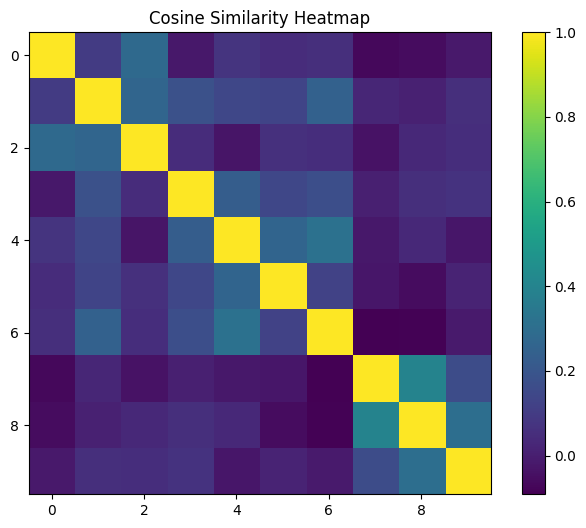


Query: The bowler took three wickets in one over
------------------------------
Match: The opening batsman played a beautiful cover drive for four.
Score: 0.5203

Match: Winning the toss is a huge advantage in day-night matches.
Score: 0.3236



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Sentences
my_sentences = [
    "The opening batsman played a beautiful cover drive for four.",
    "Spinners are usually more effective on dry, dusty pitches.",
    "Winning the toss is a huge advantage in day-night matches.",
    "A pinch of salt can really bring out the sweetness in chocolate.",
    "Slowly sauté the onions until they turn a golden brown color.",
    "Always let the meat rest for a few minutes after grilling it.",
    "Fresh herbs like parsley and cilantro add a nice finishing touch.",
    "Using a strong password isn't enough; you need 2FA enabled.",
    "Phishing links in emails are a common way to steal credentials.",
    "Hackers often exploit unpatched software to gain system access."
]

# Generate embeddings
embeddings = model.encode(my_sentences)

# Cosine similarity
sim_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()

# Plot heatmap (NO seaborn to avoid errors)
plt.figure(figsize=(8,6))
plt.imshow(sim_matrix)
plt.colorbar()
plt.title("Cosine Similarity Heatmap")
plt.show()

# Query
query_text = "The bowler took three wickets in one over"
query_vec = model.encode(query_text)

results = util.semantic_search(query_vec, embeddings, top_k=2)

print(f"\nQuery: {query_text}")
print("-" * 30)

for res in results[0]:
    print(f"Match: {my_sentences[res['corpus_id']]}")
    print(f"Score: {round(res['score'], 4)}\n")